In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)

In [2]:
# 新增flow matching HArmonic path class Change1
# 调omega值
# pi和0还是会return NaN, numerical processing的问题，毕竟归零项在分母
omega = math.pi / 3
# noice function sigma
# sigma = 0.2
    # sigma= 0.0 harmonic路径纯享版

# CFM的Harmonic path class
class HarmonicConditionalFlowMatcher(ConditionalFlowMatcher):
    def __init__(self, sigma=0.0, omega=math.pi/2):         ##默认omeg值pi/2
        super().__init__(sigma)
        ##Loss=not_a_number prevention
        if abs(math.sin(omega)) < 1e-8:
            raise ValueError("坏菜了，NaN")
        self.omega = omega
        self._sin_omega = math.sin(omega)
        self._cos_omega = math.cos(omega)

    ## 变量dummy：_a = (x1 - cos(ω)x0)/sin(ω) 
    ## 避免redundant code
    ## ***Notice*** numerical method处理顺序，在更复杂的情况中可能衍生逻辑不稳定导致的varied output的问题(?)
    def _a(self, x0, x1):
        ### _a = (x1 - x0*cos(w)) / sin(w)
        return (x1 - x0 * self._cos_omega) / (self._sin_omega)

    ## 轨迹函数
    ## Hamiltonian Diffusion EQN(19)
    ## 位移方程tool function
    def compute_mu_t(self, x0, x1, t):
        t = pad_t_like_x(t, x0)          ### 延展成张量,tensor size match x0
        a = self._a(x0, x1)
        ### cos(ωt)x0 + sin(ωt)/[sin(ω) * (x1 - cos(ω)x0)]
        ### cos(ωt)x0 + sin(ωt)/a
        return torch.cos(self.omega * t) * x0 + torch.sin(self.omega * t) * a
        

    ## 轨迹函数一阶导数
    ## 速度函数tool function
    def compute_conditional_flow(self, x0, x1, t, xt=None):
        ### Harmonic插值不需要t值的xt
        t = pad_t_like_x(t, x0)
        a = self._a(x0, x1)
            ## d/dt mu_t = -ω*sin(wt)*x0 + ω*cos(wt)/sin(w) * (x1 - cos(w)*x0)
            ##           = -ω*sin(wt)*x0 + ω*cos(wt)*a
        return (-self.omega * torch.sin(self.omega * t)) * x0 + (self.omega * torch.cos(self.omega * t)) * a


# OTCFM的Harmonic path class
# ExactOptimalTransportConditionalFlowMatcher库在conditional_flow_matching.py里
# Modify beneath parent class
class HarmonicExactOptimalTransportConditionalFlowMatcher(ExactOptimalTransportConditionalFlowMatcher):
    def __init__(self, sigma=0.2, omega=math.pi/2):
        ## noise function signma(常用0.5）
        super().__init__(sigma)
        if abs(math.sin(omega)) < 1e-7:
            raise ValueError("坏菜NaN")
        self.omega = omega
        self._sin_omega = math.sin(omega)
        self._cos_omega = math.cos(omega)
    ## 变量dummy：_a = (x1 - cos(ω)x0)/sin(ω)
    def _a(self, x0, x1):
        return (x1 - x0 * self._cos_omega) / (self._sin_omega)
    ## 同CFM轨迹函数
    ## 位移方程tool function
    def compute_mu_t(self, x0, x1, t):
        t = pad_t_like_x(t, x0)
        a = self._a(x0, x1)
        ### mu(t) = cos(ωt)*x0 + (sin(ωt)/sin(ω)) * (x1 - cos(ω)*x0)
        ###       = cos(ωt)*x0 + sin(ωt)*a
        return torch.cos(self.omega * t) * x0 + torch.sin(self.omega * t) * a
    ## 同CFM轨迹函数一阶导
    ## 速度函数tool function
    def compute_conditional_flow(self, x0, x1, t, xt):
        del xt
        t = pad_t_like_x(t, x0)
        a = self._a(x0, x1)
        ### d/dt[mu_t] = -ω*sin(ωt)*x0 + ω*cos(ωt)*(1/sin(ω))*(x1 - cos(ω)*x0)
        ###            = -ω*sin(ωt)*x0 + ω*cos(ωt)*a
        return (-self.omega * torch.sin(self.omega * t)) * x0 + (self.omega * torch.cos(self.omega * t)) * a


# SBCFM的Harmonic path class
# SchrodingerBridgeConditionalFlowMatcher库也在conditional_flow_matching.py里
# Modification beneath parent class
class HarmonicSchrodingerBridgeConditionalFlowMatcher(SchrodingerBridgeConditionalFlowMatcher):
    def __init__(self, sigma=1.0, omega=math.pi/2, ot_method="exact"):
        ## noise function sigma(常用1.0）
        super().__init__(sigma=sigma, ot_method=ot_method)
        if abs(math.sin(omega)) < 1e-7:
            raise ValueError("loss function 会report NaN")
        self.omega = omega
        self._sin_omega = math.sin(omega)
        self._cos_omega = math.cos(omega)
    ## dummy var _a同上
    def _a(self, x0, x1):
        return (x1 - x0 * self._cos_omega) / (self._sin_omega)
        ### 加了受限阈值***DISREGARD***小值会让gradient descent有很大momentum（轨迹向外漂）
        ###越接近endpoint漂移就越严重
    ## mu_t方程同上
    def compute_mu_t(self, x0, x1, t):
        t = pad_t_like_x(t, x0)
        a = self._a(x0, x1)
        return torch.cos(self.omega * t) * x0 + torch.sin(self.omega * t) * a
    ## d/dt[mu_t]位移一阶导方程同上
    def _dmu_dt(self, x0, x1, t):
        t = pad_t_like_x(t, x0)
        a = self._a(x0, x1)
        return (-self.omega * torch.sin(self.omega * t)) * x0 + (self.omega * torch.cos(self.omega * t)) * a

    def compute_conditional_flow(self, x0, x1, t, xt):
        t = pad_t_like_x(t, x0)
        mu_t = self.compute_mu_t(x0, x1, t)
        ##SB特殊项
        sigma_t_prime_over_sigma_t = (1 - 2 * t) / (2 * t * (1 - t))
        return sigma_t_prime_over_sigma_t * (xt - mu_t) + self._dmu_dt(x0, x1, t)


### Conditional Flow Matching

5000: loss 10.999 time 23.46


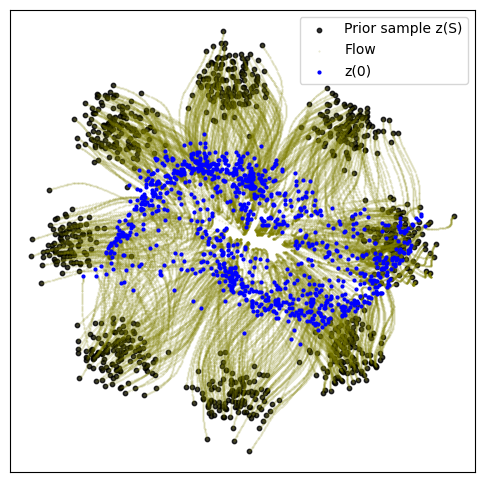

10000: loss 10.811 time 25.43


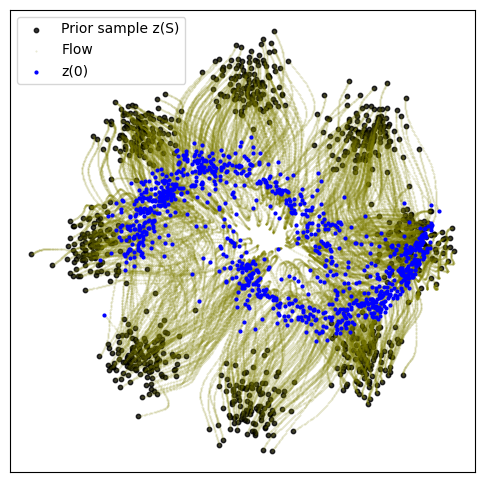

15000: loss 10.516 time 26.66


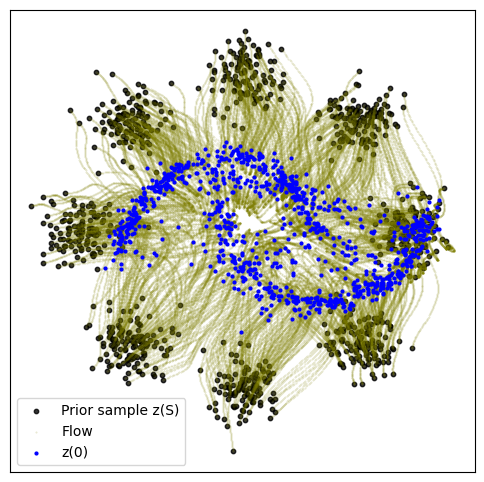

20000: loss 10.694 time 26.00


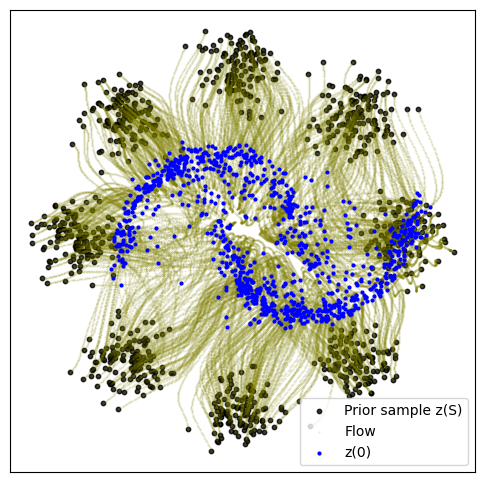

CPU times: user 1min 41s, sys: 5.65 s, total: 1min 46s
Wall time: 1min 44s


In [3]:
%%time
sigma = 0.2
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
## Change2
## 换成Harmonic_Path_FM
## 调用hyper-parameter Omega
FM = HarmonicConditionalFlowMatcher(sigma=sigma, omega=omega)
##FM = ConditionalFlowMatcher(sigma=sigma)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size)
    x1 = sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/cfm_v1.pt")


### Optional Transport Conditional Flow Matching

5000: loss 0.265 time 68.81


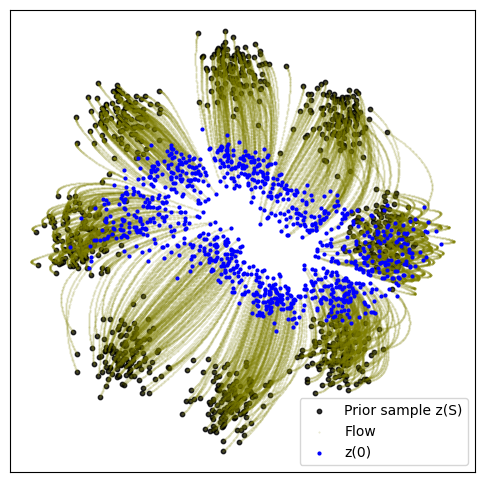

10000: loss 0.236 time 343.65


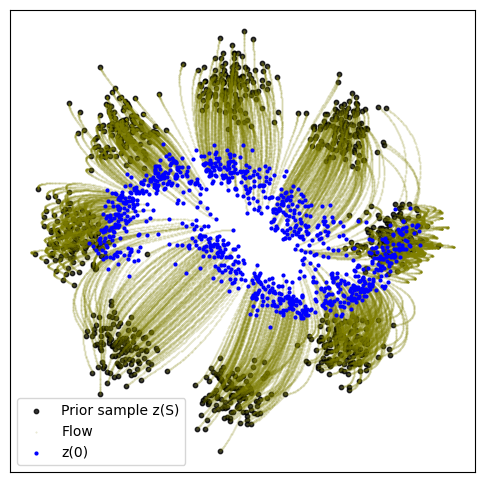

15000: loss 0.379 time 72.77


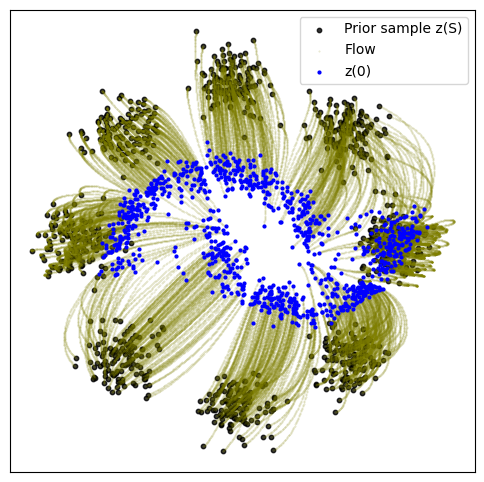

20000: loss 0.254 time 71.01


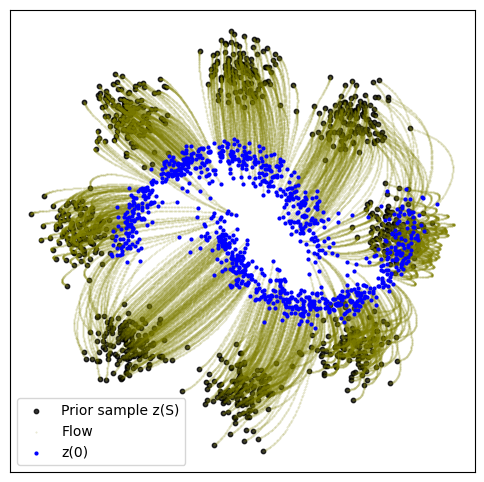

CPU times: user 4min 33s, sys: 14.7 s, total: 4min 48s
Wall time: 9min 18s


In [4]:
%%time
sigma = 0.2
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
##FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
##Change3
FM = HarmonicExactOptimalTransportConditionalFlowMatcher(sigma=sigma, omega=omega)

start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size)
    x1 = sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time() 
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/otcfm_v1.pt")

### Schrödinger Bridge Conditional Flow Matching

5000: loss 1.882 time 69.07


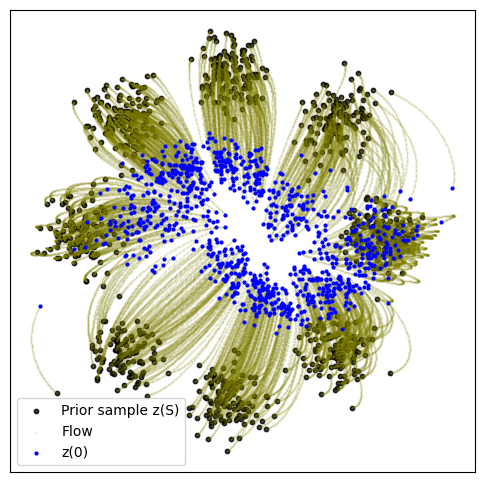

10000: loss 0.751 time 73.70


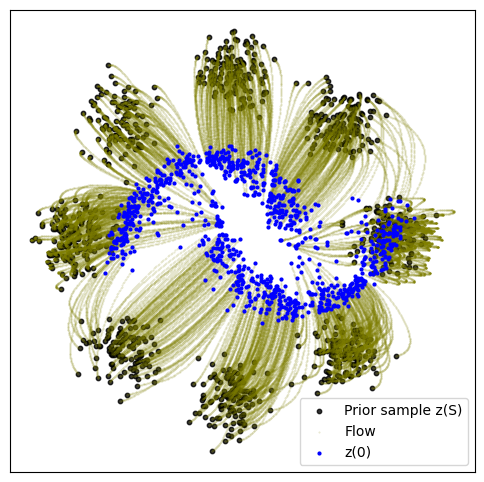

15000: loss 1.397 time 72.96


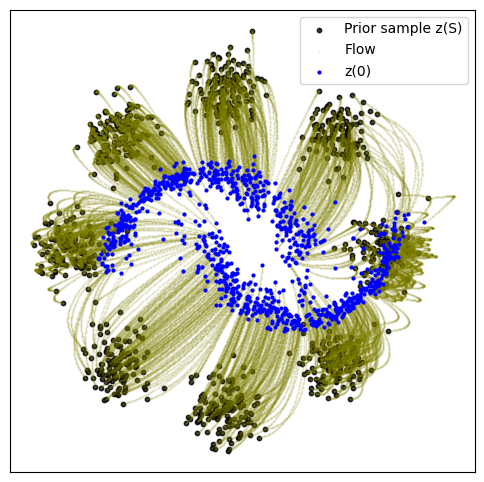

20000: loss 2.866 time 74.27


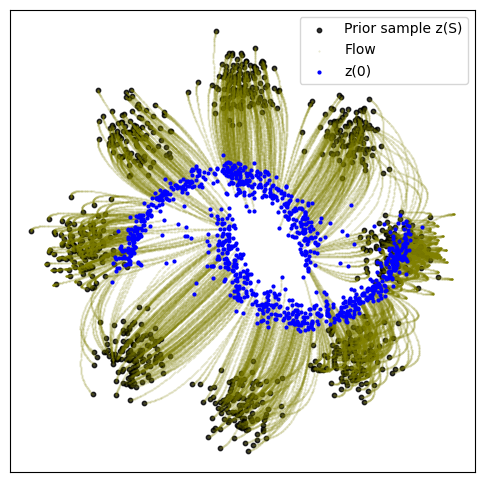

CPU times: user 4min 36s, sys: 16.8 s, total: 4min 52s
Wall time: 4min 52s


In [5]:
%%time
sigma = 0.5
dim = 2
batch_size = 256
model = MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
# For best performance, use ot_method="exact". To follow the theory, use ot_method="sinkhorn"
##FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma, ot_method="exact")
##Change4
FM = HarmonicSchrodingerBridgeConditionalFlowMatcher(sigma=sigma, omega=omega, ot_method="exact")


start = time.time()
for k in range(20000):
    optimizer.zero_grad()

    x0 = sample_8gaussians(batch_size)
    x1 = sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/sbcfm_v1.pt")